In [4]:
using Pkg
Pkg.activate(".")
Pkg.status()

  Activating project at `c:\Users\ikuto\Documents\Research_code\MCMC`


Status `C:\Users\ikuto\Documents\Research_code\MCMC\Project.toml`
  [31c24e10] Distributions v0.25.120
  [91a5bcdd] Plots v1.40.17
  [9a3f8284] Random v1.11.0


### 採択ー棄却法（accept-reject method）

In [5]:
using Distributions, Random, Plots

[ Info: Precompiling Distributions [31c24e10-a181-5473-b8eb-7969acd0382f] (cache misses: incompatible header (4))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (4), incompatible header (6))
[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] (cache misses: wrong dep version loaded (2), incompatible header (4))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (4), incompatible header (2))


候補サンプルを生成する提案密度 $q(\mathbf{\theta}|\mathbf{y})$ と定数$c$によって特徴づけられ、すべての $\mathbf{\theta} \in \Theta$ に対して  
\begin{equation}
\pi(\mathbf{\theta}|\mathbf{y}) \le cq(\mathbf{\theta}|\mathbf{y})
\end{equation}
となる。ここで、 $c = sup_{\theta \in \Theta} {\frac{\pi(\mathbf{\theta}|\mathbf{y})}{q(\mathbf{\theta}|\mathbf{y})}}$ である。$\pi$ の正規化定数は定数 $c$ に吸収されるので、その知識は必要ない。  
採択棄却法では、提案密度 $q$ から発生された候補が確率 $\frac{\pi(\mathbf{\theta}|\mathbf{y})}{cq(\mathbf{\theta}|\mathbf{y})}$ で採択される。もしもその候補が棄却された場合は新しい候補を発生させる。そのプロセスを候補が採択されるまで繰り返す。採択された候補は $\pi$ からの独立同一分布のサンプルとなる。この方法の効率性は定数 $c$ に依存する。

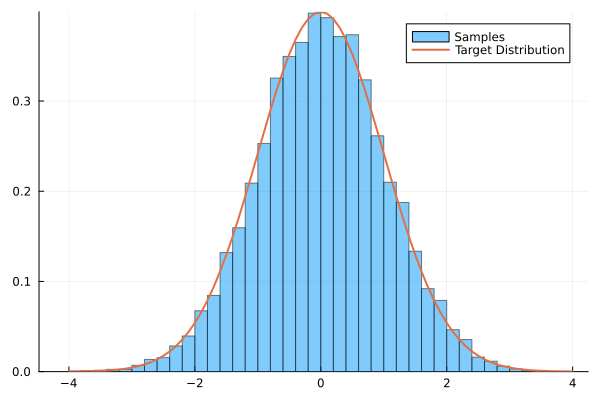

In [8]:
# 目標分布：標準正規分布
p(x) = pdf(Normal(0, 1), x)

# 提案分布：一様分布
q = Uniform(-10, 10)
qpdf(x) = pdf(q, x)

# 定数 c の計算
c = maximum(p(x) / qpdf(x) for x in -10:0.01:10)

# 採択棄却法の実装
function accept_reject(p, q, c, N)
    samples = Float64[]
    while length(samples) < N
        x = rand(q)
        u = rand()
        if u < p(x) / (c * qpdf(x))
            push!(samples, x)
        end
    end
    return samples
end

# サンプル生成
samples = accept_reject(p, q, c, 10_000)

# ヒストグラムのプロット
histogram(samples, bins=50, normalize=true, label="Samples", alpha=0.5)
x = -4:0.1:4
plot!(x, p.(x), label="Target Distribution", lw=2)

### 重点サンプリング

複雑な分布から直接サンプリングできないときに、別の簡単な分布を使って期待値を計算する方法。 
以下の事後分布の期待値の計算に興味があるとする。 
\begin{equation}
I = \int_{\Theta}h(\mathbf{\theta})\pi(\mathbf{\theta}|y)d\mathbf{\theta}
\end{equation}  
> 重点サンプリング
1. 提案分布 $q(\mathbf{\theta})$ から $N$ 個のサンプル ${\mathbf{\theta^{(i)}}}^N_{i=1}$ を生成
2. 各点での重みを計算：
\begin{equation*}
w^{(i)} = \frac{\pi(\mathbf{\theta^{(i)}}|\mathbf{y})}{q(\mathbf{\theta}^{(i)})}
\end{equation*}
3. 正規化された重みで期待値を近似：
\begin{equation*}
\hat{I} = \sum^N_{i=1}h(\mathbf{\theta}^{(i)})\frac{w^{(i)}}{\sum^N_{j=1}w^{(j)}}
\end{equation*}  
  
> SIR法  
アイデア；重点サンプリングの重み付きサンプルは「扱いづらい」  
→　重みに比例してサンプルを再抽出することで「事後分布に従うような標本」を直接得る。  
1. 重点サンプリングの2まで同じ
2. 重みに基づいて再標本抽出（重複あり）して、新たに $N$ 個の「重み無しサンプル」${\tilde{\mathbf{\theta}}^{(i)}}^N_{i=1}$ を得る。→　重みが大きいサンプルは何回も選ばれやすい  
  
  真の事後分布 $\pi(\mathbf{\theta}|\mathbf{y})$ ：標準正規分布 $N(0,1)$、  
提案分布 $q(\mathbf{\theta}|\mathbf{y})$ ：正規分布 $N(0,1.5^2)$、  
関数 $h(\mathbf{\theta}) = \theta^2$  
と仮定する。  
このとき、
\begin{align*}
I &= \int_{-\infty}^{\infty} \theta^2 \, \pi(\theta \mid y) \, d\theta \\
  &= \mathbb{E}_{\pi}[\theta^2] \\
  &= \operatorname{Var}(\theta) + \left( \mathbb{E}[\theta] \right)^2 \\
  &= 1 + 0 \\
  &= 1
\end{align*}
 
→　サンプリングでも期待値が1に近づくことを確かめる。


In [19]:
using StatsBase

# 事後分布
_p = Normal(0, 1)

# 提案分布
_q = Normal(0, 1.5)

# 関数h(θ)
h(θ) = θ^2

# サンプル数
N = 10_000

# 提案分布からのサンプル
θ_samples = rand(q, N)

# 重み w_i = π(θ_i) / q(θ_i)
weights = pdf.(_p, θ_samples) ./ pdf.(_q, θ_samples)

# 正規化された重み
norm_weights = weights ./ sum(weights)

10000-element Vector{Float64}:
 1.2945418197246192e-9
 2.9611422177540758e-15
 1.3985493746840992e-7
 0.00015318821110632403
 5.495935748113776e-13
 3.212778596944918e-14
 3.656780056900651e-10
 0.0005802988485777018
 3.888854652890764e-10
 0.00024017240744128772
 0.00014682906867825093
 2.7810084187916725e-14
 1.391582083545824e-10
 ⋮
 0.00010771562329646026
 9.921348856965759e-5
 1.1426535163429075e-5
 3.2738246633183845e-6
 1.1532915610678007e-14
 4.8944440507205844e-5
 6.862879642647405e-7
 1.929159224733265e-5
 0.00044752936064452255
 1.410170151144272e-6
 0.0003923760195316505
 0.0005449030198039262

In [20]:
# 重点サンプリング

# 期待値　I ≈ Σ h(θ_i) * w_i / N
I_IS = mean(h.(θ_samples) .* weights)

println("重点サンプリングによる期待値の推定: ", I_IS)

重点サンプリングによる期待値の推定: 0.4665443118467096


In [21]:
# SIR法

# 重みに比例して再サンプリング
θ_resampled = sample(θ_samples, Weights(norm_weights), N)

I_SIR = mean(h.(θ_resampled))

println("SIR法による期待値の推定: ", I_SIR)

SIR法による期待値の推定: 1.7885447866090056


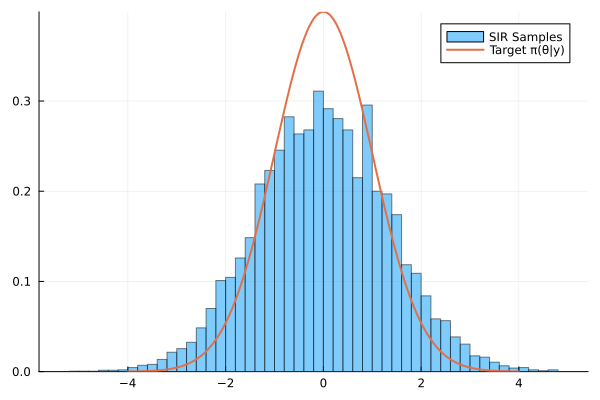

In [22]:
histogram(θ_resampled, bins=50, normalize=true, alpha=0.5, label="SIR Samples")
plot!(x -> pdf(_p, x), -4, 4, lw=2, label="Target π(θ|y)")

### メトロポリスーヘイスティングアルゴリズム

目標密度 $\pi(\mathbf{\theta}|\mathbf{y})$ のサンプリングに興味があるとする。  
M-Hアルゴリズムの背後にあるアイデアは、マルコフ遷移密度（遷移核）$K(\mathbf{\theta},\mathbf{\theta^{\dag}|\mathbf{y}})$ （$\mathbf{\theta^{\dag}|\mathbf{y}}$ → $\mathbf{\theta}$ に遷移することを表している）の代わりに扱いやすい遷移密度 $q(\mathbf{\theta},\mathbf{\theta^{\dag}|\mathbf{y}})$ を提案分布として利用し、マルコフ連鎖が正しい範囲に制限された分布を持つことを保証するように遷移密度を修正することにある。  
$\mathbf{\theta}^{(g)}$ を現在の値とし、 $\mathbf{\theta}^{(g+1)}$ を提案ステップと移動ステップの2つの手続きにより生成する。  
  
  > アルゴリズム（メトロポリス-ヘイスティング）  
  1. 初期化 $\mathbf{\theta}^{(0)}$
  2. 各繰り返しに対して $g(=1,...,n_0+G)$、  
  * **提案ステップ**：$q(\mathbf{\theta}^{(g)},\mathbf{\theta|\mathbf{y}})$ から提案された候補 $\mathbf{\theta}^{\dag}$ を抽出し、詳細つり合い条件
  \begin{equation*}
  \pi(\mathbf{\theta}|\mathbf{y})q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})\alpha(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) = \pi(\mathbf{\theta}^{\dag}|\mathbf{y})q(\mathbf{\theta}^{\dag},\mathbf{\theta}|\mathbf{y})\alpha(\mathbf{\theta}^{\dag},\mathbf{\theta}|\mathbf{y})
  \end{equation*}
  を満たすように以下の採択確率を設計する（ $\alpha(\mathbf{\theta}^{\dag},\mathbf{\theta}|\mathbf{y}) = 1$ としている ）。  
  → 詳細つり合い条件を満たすように設計すれば、普遍性および可逆性が満たされる。
  \begin{equation*}
  \alpha(\mathbf{\theta}^{(g)},\mathbf{\theta^{\dag}|\mathbf{y}}) = \min \Big\{1,\frac{\pi(\mathbf{\theta}^{\dag}|\mathbf{y})}{\pi(\mathbf{\theta}^{(g)}|\mathbf{y})}\frac{q(\mathbf{\theta}^{\dag},\mathbf{\theta}^{(g)}|\mathbf{y})}{q(\mathbf{\theta}^{(g)},\mathbf{\theta^{\dag}|\mathbf{y}})}\Big\}
  \end{equation*}
  * **移動ステップ**：
  \begin{equation*}
  \mathbf{\theta}^{(g+1)} = \left\{
    \begin{aligned}
    \mathbf{\theta}^{\dag}\qquad(\alpha(\mathbf{\theta}^{(g)},\mathbf{\theta^{\dag}|\mathbf{y}})の確率で)\\  
    \mathbf{\theta}^{(g)}\qquad(1 - \alpha(\mathbf{\theta}^{(g)},\mathbf{\theta^{\dag}|\mathbf{y}})の確率で)
    \end{aligned}
  \right.
  \end{equation*}
  3. 最初の $n_0$ 回のサンプルは捨て、$G$ 個の部分サンプル $\mathbf{\theta}^{n_0+1},...,\mathbf{\theta}^{n_0+G}$ を保存する。

提案密度が $q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) = q(\mathbf{\theta}^{\dag},\mathbf{\theta}|\mathbf{y})$ を満たすなら、確率 $\alpha(\mathbf{\theta}^{(g)},\mathbf{\theta^{\dag}|\mathbf{y}})$ は、
\begin{equation*}
\min\left\{1,\frac{\pi(\mathbf{\theta}^{\dag}|\mathbf{y})}{\pi(\mathbf{\theta}^{(g)}|\mathbf{y})}\right\}
\end{equation*}  
として簡略化される。（ランダムウォーク型M-Hアルゴリズム）

* M-H 連鎖の遷移密度  
遷移密度 $K(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})$ は2つの構成要素をもつ。  
1つ目は、 $\mathbf{\theta}$ から移動する（$\mathbf{\theta}^{\dag} \ne \mathbf{\theta}$）ための構成要素
\begin{equation*}
\alpha(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})
\end{equation*}  
であり、もう1つは、 $\mathbf{\theta}$ に留まろうとする（$\mathbf{\theta}^{\dag} = \mathbf{\theta}$）構成要素
\begin{equation*}
r(\mathbf{\theta}|\mathbf{y}) = 1 - \int\alpha(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})d\mathbf{\theta}^{\dag}
\end{equation*}  
である。つまり、  
\begin{equation*}
K(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) = \alpha(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y})q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) + \delta_{\mathbf{\theta}}(\mathbf{\theta}^{\dag})r(\mathbf{\theta}|\mathbf{y})
\end{equation*}
となる。  
ここで、 $\delta_{\mathbf{\theta}}(\mathbf{\theta}^{\dag})$ はディラック関数、 $\mathbf{\theta}^{\dag} \ne \mathbf{\theta}$ に対して $\delta_{\mathbf{\theta}}(\mathbf{\theta}^{\dag}) = 0, かつ \int\delta_{\mathbf{\theta}}(\mathbf{\theta}^{\dag})d\mathbf{\theta}^{\dag} = 1$ である。

* 提案密度の選び方  
  
  **ランダムウォーク提案密度**  
  現在の値を $\mathbf{\theta}$ とすると、候補を
  \begin{equation*}
  \mathbf{\theta}^{\dag} = \mathbf{\theta} + \mathbf{z}
  \end{equation*}
  とする。ここで、 $\mathbf{z}$ は対称分布（例えば、望ましい採択率になるように調整された平均0、分散共分散行列 $\tau\mathbf{V}$ の多変量正規分布など）に従う。  
  その分布の対称性(☆)から $q(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) = q(\mathbf{\theta}^{\dag},\mathbf{\theta}|\mathbf{y})$ であり、$q$ の項がキャンセルされるため採択確率は
  \begin{equation*}
  \alpha(\mathbf{\theta},\mathbf{\theta}^{\dag}|\mathbf{y}) = \min\left\{1,\frac{\pi(\mathbf{\theta}^{\dag}|\mathbf{y})}{\pi(\mathbf{\theta}|\mathbf{y})}\right\}
  \end{equation*}
  と単なる目標密度の関数として簡略化される。  

    (☆)の証明(多分)：  
    $\mathbf{\theta}^{\dag} = \mathbf{\theta} + \mathbf{z} \sim \mathbf{N}(\mathbf{\theta},\tau^2)$ より提案密度も $\mathbf{N}(\mathbf{\theta},\tau^2)$ に従う。  $$q(\mathbf{\theta}^{\dag}|\mathbf{\theta}) = \frac{1}{\sqrt{2\pi\tau^2}}\exp\Big(-\frac{(\mathbf{\theta}^{\dag}-\mathbf{\theta})^2}{2\tau^2}\Big)\\q(\mathbf{\theta}|\mathbf{\theta}^{\dag}) = \frac{1}{\sqrt{2\pi\tau^2}}\exp\Big(-\frac{(\mathbf{\theta}-\mathbf{\theta}^{\dag})^2}{2\tau^2}\Big)$$  $(\mathbf{\theta}^{\dag}-\mathbf{\theta})^2 = (\mathbf{\theta}-\mathbf{\theta}^{\dag})^2$ なので上の二つの式は全く同じ。したがって対称性が成り立つ。  
      
  **独立な提案密度**  
    独立M-H連鎖　省略
  
  


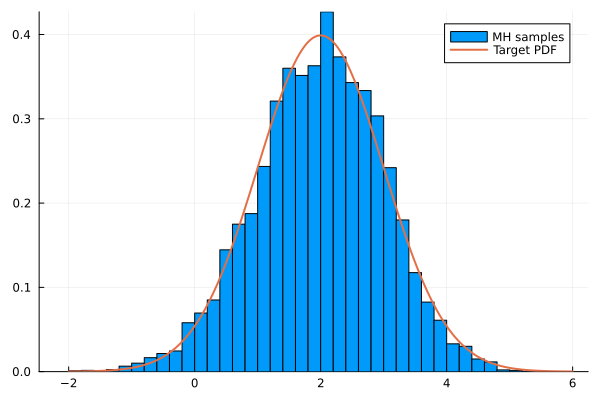

In [ ]:
# メトロポリスーヘイスティングアルゴリズム
"""
目標分布：正規分布 N(2,1)
提案分布：指数分布
"""

using Distributions, Random, StatsPlots

# 目標分布
target_dist = Normal(2.0, 1.0)
logπ(θ) = logpdf(target_dist, θ)

# 提案分布（ランダムウォーク提案密度を採用）
function q_propose(θ::Float64)
    δ = rand(Exponential(1.0))
    δ *= rand() < 0.5 ? -1.0 : 1.0  # ランダムウォーク
    return θ + δ
end

# 提案分布の密度（非対称なので左右で異なる）
function q_density(from::Float64, to::Float64)
    δ = to - from
    if δ > 0
        return pdf(Exponential(1.0), δ)
    else
        return pdf(Exponential(1.0), -δ)
    end
end

# MH アルゴリズムの実行
function metropolis_hastings(logπ, q_propose, q_density, θ₀::Float64, N::Int)
    θ_samples = Float64[]
    θ = θ₀
    push!(θ_samples, θ)

    for i in 1:N
        θ_proposed = q_propose(θ)

        log_accept_ratio = logπ(θ_proposed) - logπ(θ) +
            log(q_density(θ_proposed, θ)) - log(q_density(θ, θ_proposed))

        if log(rand()) < log_accept_ratio
            θ = θ_proposed
        end
        push!(θ_samples, θ)
    end

    return θ_samples
end

# 実行
Random.seed!(123)
samples = metropolis_hastings(logπ, q_propose, q_density, 0.0, 10_000)

# 可視化
histogram(samples; bins=50, normalize=true, label="MH samples")
plot!(x -> pdf(target_dist, x), -2:0.01:6, label="Target PDF", lw=2)

### Turing.jlをつかって実装

Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00


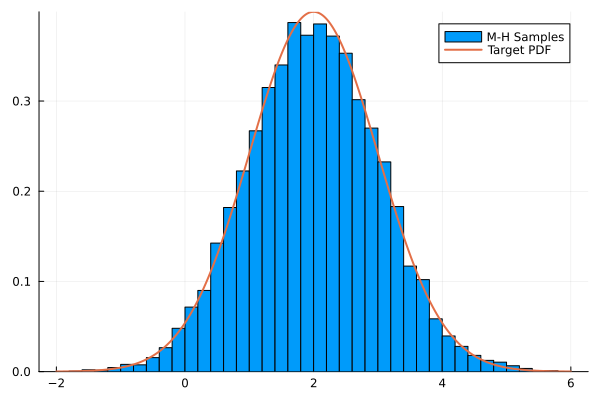

In [ ]:
# M-Hアルゴリズムの実装

using Turing, Distributions, Random, StatsPlots

@model function mh_model()
    θ ~ Normal(2.0, 1.0) # 目標分布
end

# 提案分布はTuring.jl側が自動的に決定

Random.seed!(123)

# M-Hアルゴリズムの指定
samples = sample(mh_model(), MH(), 10_000)

θ_samples = samples[:θ]
histogram(θ_samples, bins=50, normalize=true, label="M-H Samples")
plot!(x -> pdf(Normal(2.0, 1.0), x), -2:0.01:6, label="Target PDF", lw=2)